# Mutual Fund Analytics – Performance Analytics

**Intern:** Shyam

**Project:** Mutual Fund Analytics Platform

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
# Load datasets

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

print("Datasets Loaded Successfully!")

print("\nNAV Shape:", nav_df.shape)
print("Performance Shape:", performance_df.shape)
print("Benchmark Shape:", benchmark_df.shape)

Datasets Loaded Successfully!

NAV Shape: (46000, 3)
Performance Shape: (40, 19)
Benchmark Shape: (8050, 3)


In [3]:
print(benchmark_df.head())

print("\nColumns:")
print(benchmark_df.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Columns:
Index(['date', 'index_name', 'close_value'], dtype='object')


# Task 1 - Daily Return Calculation

In [4]:
# Convert date column
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort values
nav_df = nav_df.sort_values(["amfi_code", "date"])

# Calculate daily return
nav_df["daily_return"] = (
    nav_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav_df.head(15))

    amfi_code       date       nav  daily_return
0      100016 2022-01-03  520.4608           NaN
1      100016 2022-01-04  515.0971     -0.010306
2      100016 2022-01-05  521.7239      0.012865
3      100016 2022-01-06  515.7880     -0.011377
4      100016 2022-01-07  515.1639     -0.001210
5      100016 2022-01-10  510.7136     -0.008639
6      100016 2022-01-11  513.5542      0.005562
7      100016 2022-01-12  512.3195     -0.002404
8      100016 2022-01-13  510.2445     -0.004050
9      100016 2022-01-14  514.3636      0.008073
10     100016 2022-01-17  514.7627      0.000776
11     100016 2022-01-18  517.3803      0.005085
12     100016 2022-01-19  513.1866     -0.008106
13     100016 2022-01-20  507.1294     -0.011803
14     100016 2022-01-21  507.8710      0.001462


## Daily Return Distribution

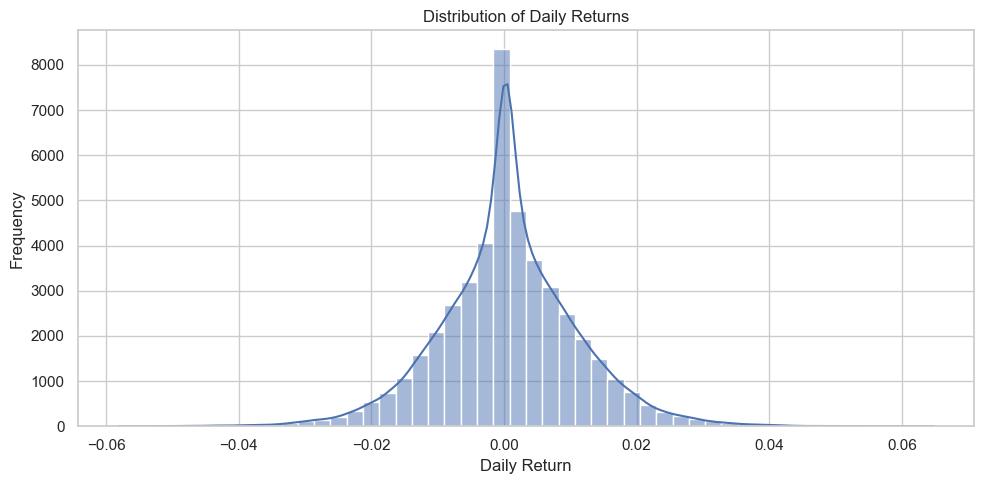

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Observation 1

The daily return distribution is centered close to zero with most observations clustered around small positive and negative returns. This indicates that the calculated daily returns are realistic for mutual fund NAV movements.

# Task 2 - CAGR Calculation (1 Year, 3 Year, 5 Year)

In [8]:
from pandas.tseries.offsets import DateOffset

cagr_results = []

for fund in nav_df["amfi_code"].unique():

    fund_data = (
        nav_df[nav_df["amfi_code"] == fund]
        .sort_values("date")
        .reset_index(drop=True)
    )

    latest_date = fund_data["date"].max()
    latest_nav = fund_data.iloc[-1]["nav"]

    result = {"amfi_code": fund}

    for yrs in [1, 3, 5]:

        target_date = latest_date - DateOffset(years=yrs)

        eligible = fund_data[fund_data["date"] <= target_date]

        if len(eligible) == 0:
            result[f"CAGR_{yrs}Y"] = np.nan
            continue

        start_nav = eligible.iloc[-1]["nav"]

        cagr = ((latest_nav / start_nav) ** (1 / yrs) - 1) * 100

        result[f"CAGR_{yrs}Y"] = round(cagr, 2)

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.head())

   amfi_code  CAGR_1Y  CAGR_3Y  CAGR_5Y
0     100016    -2.22     1.29      NaN
1     100025     3.70     3.92      NaN
2     100033    53.23    32.44      NaN
3     101206    47.92    28.97      NaN
4     101207   -23.99    -4.15      NaN


### Observation 2

One-year and three-year CAGR values were successfully calculated for all schemes based on available NAV history. Five-year CAGR is unavailable because the dataset does not contain a full five years of historical NAV data.

In [9]:
cagr_df.to_csv("../data/processed/cagr_comparison.csv", index=False)

print("Saved cagr_comparison.csv")

Saved cagr_comparison.csv


# Task 3 - Sharpe Ratio

In [10]:
risk_free_rate = 0.065

sharpe_results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = (
        nav_df[nav_df["amfi_code"] == fund]["daily_return"]
        .dropna()
    )

    mean_return = fund_returns.mean() * 252
    std_return = fund_returns.std() * np.sqrt(252)

    if std_return == 0:
        sharpe = np.nan
    else:
        sharpe = (mean_return - risk_free_rate) / std_return

    sharpe_results.append({
        "amfi_code": fund,
        "Sharpe_Ratio": round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["Sharpe_Rank"] = sharpe_df.index + 1

print(sharpe_df.head())

   amfi_code  Sharpe_Ratio  Sharpe_Rank
0     148567        1.4483            1
1     120843        1.3067            2
2     148569        1.2349            3
3     119551        1.2083            4
4     120505        1.1801            5


### Observation 3

Funds with higher Sharpe Ratios generated better risk-adjusted returns, indicating more efficient performance relative to their volatility.

In [11]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Saved sharpe_ratio.csv")

Saved sharpe_ratio.csv


# Task 4 - Sortino Ratio

In [12]:
# Annual risk-free rate
risk_free_rate = 0.065

sortino_results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = (
        nav_df.loc[nav_df["amfi_code"] == fund, "daily_return"]
        .dropna()
    )

    if len(fund_returns) == 0:
        continue

    # Annualized return
    annual_return = fund_returns.mean() * 252

    # Downside returns only
    downside_returns = fund_returns[fund_returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std() * np.sqrt(252)

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (annual_return - risk_free_rate) / downside_std

    sortino_results.append({
        "amfi_code": fund,
        "Sortino_Ratio": round(sortino, 4)
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["Sortino_Rank"] = sortino_df.index + 1

print(sortino_df.head())

   amfi_code  Sortino_Ratio  Sortino_Rank
0     148567         2.3856             1
1     120843         2.3643             2
2     148569         2.1469             3
3     119551         2.1403             4
4     120505         2.0294             5


### Observation 4

The Sortino Ratio evaluates fund performance by considering only downside volatility. Funds with higher Sortino Ratios delivered stronger returns while exposing investors to lower downside risk.

In [13]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Saved sortino_ratio.csv")

Saved sortino_ratio.csv


# Task 5 - Maximum Drawdown

In [14]:
drawdown_results = []

for fund in nav_df["amfi_code"].unique():

    fund_data = (
        nav_df[nav_df["amfi_code"] == fund]
        .sort_values("date")
        .copy()
    )

    # Running maximum NAV
    fund_data["running_max"] = fund_data["nav"].cummax()

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    # Worst drawdown
    worst_idx = fund_data["drawdown"].idxmin()

    drawdown_results.append({
        "amfi_code": fund,
        "Max_Drawdown (%)": round(
            fund_data.loc[worst_idx, "drawdown"] * 100,
            2
        ),
        "Worst_Drawdown_Date": fund_data.loc[
            worst_idx,
            "date"
        ]
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df = drawdown_df.sort_values(
    "Max_Drawdown (%)"
).reset_index(drop=True)

drawdown_df["Drawdown_Rank"] = (
    drawdown_df["Max_Drawdown (%)"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

print(drawdown_df.head())

   amfi_code  Max_Drawdown (%) Worst_Drawdown_Date  Drawdown_Rank
0     119599            -52.57          2025-10-28             40
1     119095            -51.68          2026-05-11             39
2     101207            -35.45          2026-05-11             38
3     149324            -31.17          2025-01-03             37
4     119598            -28.71          2025-05-14             36


### Observation 5

Maximum Drawdown measures the largest decline from a historical peak in NAV. Funds with smaller drawdowns generally exhibited better downside protection during market corrections.

In [15]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("Saved max_drawdown.csv")

Saved max_drawdown.csv


In [16]:
benchmark_df["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [17]:
benchmark_df.head(10)

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
5,2022-01-10,NIFTY50,18124.84
6,2022-01-11,NIFTY50,18256.96
7,2022-01-12,NIFTY50,18162.54
8,2022-01-13,NIFTY50,18179.05
9,2022-01-14,NIFTY50,17971.75


# Task 6 - Alpha and Beta (NIFTY100 Benchmark)

In [18]:
# Prepare benchmark data (NIFTY100)

benchmark = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

alpha_beta_results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        ["date", "amfi_code", "daily_return"]
    ]

    fund_returns = fund_returns[
        fund_returns["amfi_code"] == fund
    ].copy()

    merged = pd.merge(
        fund_returns,
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope
    alpha = regression.intercept * 252

    alpha_beta_results.append({

        "amfi_code": fund,

        "Alpha": round(alpha,6),

        "Beta": round(beta,4)

    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
)

print(alpha_beta_df.head())

    amfi_code     Alpha    Beta
21     119598  0.303370 -0.0232
39     149324  0.300579  0.0115
25     120505  0.292636  0.0005
36     148569  0.282704  0.0181
30     120843  0.273305 -0.0228


### Observation 6

Alpha measures a fund's excess return over the benchmark after adjusting for market risk, while Beta indicates the sensitivity of fund returns relative to the NIFTY100 index.

In [19]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Saved alpha_beta.csv")

Saved alpha_beta.csv


# Task 7 - Fund Scorecard (0–100)

In [20]:
# Merge all required metrics

scorecard = performance_df.copy()

# 3-Year Return Rank (Higher is Better)
scorecard["Return3Y_Rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False, method="dense")
)

# Merge Sharpe
scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Rank"]],
    on="amfi_code",
    how="left"
)

# Alpha Rank
alpha_beta_df["Alpha_Rank"] = (
    alpha_beta_df["Alpha"]
    .rank(ascending=False, method="dense")
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha_Rank"]],
    on="amfi_code",
    how="left"
)

# Expense Ratio Rank (Lower is Better)
scorecard["Expense_Rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True, method="dense")
)

# Drawdown Rank (Smaller loss is Better)
drawdown_df["Drawdown_Rank"] = (
    drawdown_df["Max_Drawdown (%)"]
    .rank(ascending=False, method="dense")
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Drawdown_Rank"]],
    on="amfi_code",
    how="left"
)

# Weighted Score
scorecard["Raw_Score"] = (
      0.30 * scorecard["Return3Y_Rank"]
    + 0.25 * scorecard["Sharpe_Rank"]
    + 0.20 * scorecard["Alpha_Rank"]
    + 0.15 * scorecard["Expense_Rank"]
    + 0.10 * scorecard["Drawdown_Rank"]
)

# Convert to 0-100
max_score = scorecard["Raw_Score"].max()
min_score = scorecard["Raw_Score"].min()

scorecard["Fund_Score"] = (
    100
    - (
        (scorecard["Raw_Score"] - min_score)
        / (max_score - min_score)
    ) * 100
).round(2)

# Final Ranking
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard["Overall_Rank"] = range(
    1,
    len(scorecard) + 1
)

print(
    scorecard[
        [
            "Overall_Rank",
            "scheme_name",
            "Fund_Score"
        ]
    ].head(10)
)

    Overall_Rank                                        scheme_name  \
12             1           ICICI Pru Midcap Fund - Regular - Growth   
22             2             Kotak Flexicap Fund - Regular - Growth   
7              3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
2              4         SBI Small Cap Fund - Regular Plan - Growth   
34             5      Mirae Asset Large Cap Fund - Regular - Growth   
39             6              DSP Small Cap Fund - Regular - Growth   
38             7                 DSP Midcap Fund - Regular - Growth   
11             8          ICICI Pru Bluechip Fund - Direct - Growth   
26             9                Axis Midcap Fund - Regular - Growth   
36            10      Mirae Asset Tax Saver Fund - Regular - Growth   

    Fund_Score  
12      100.00  
22       99.54  
7        93.74  
2        93.27  
34       92.11  
39       83.29  
38       83.06  
11       76.33  
26       75.64  
36       71.93  


### Observation 7

The composite Fund Score combines return, risk-adjusted performance, alpha generation, expense efficiency, and downside protection into a single ranking, enabling an overall comparison of mutual fund quality.

In [21]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Saved fund_scorecard.csv")

Saved fund_scorecard.csv


# Task 8 - Benchmark Comparison (Top 5 Funds vs NIFTY50 & NIFTY100)

In [26]:
# Prepare benchmark data

benchmark = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()
)

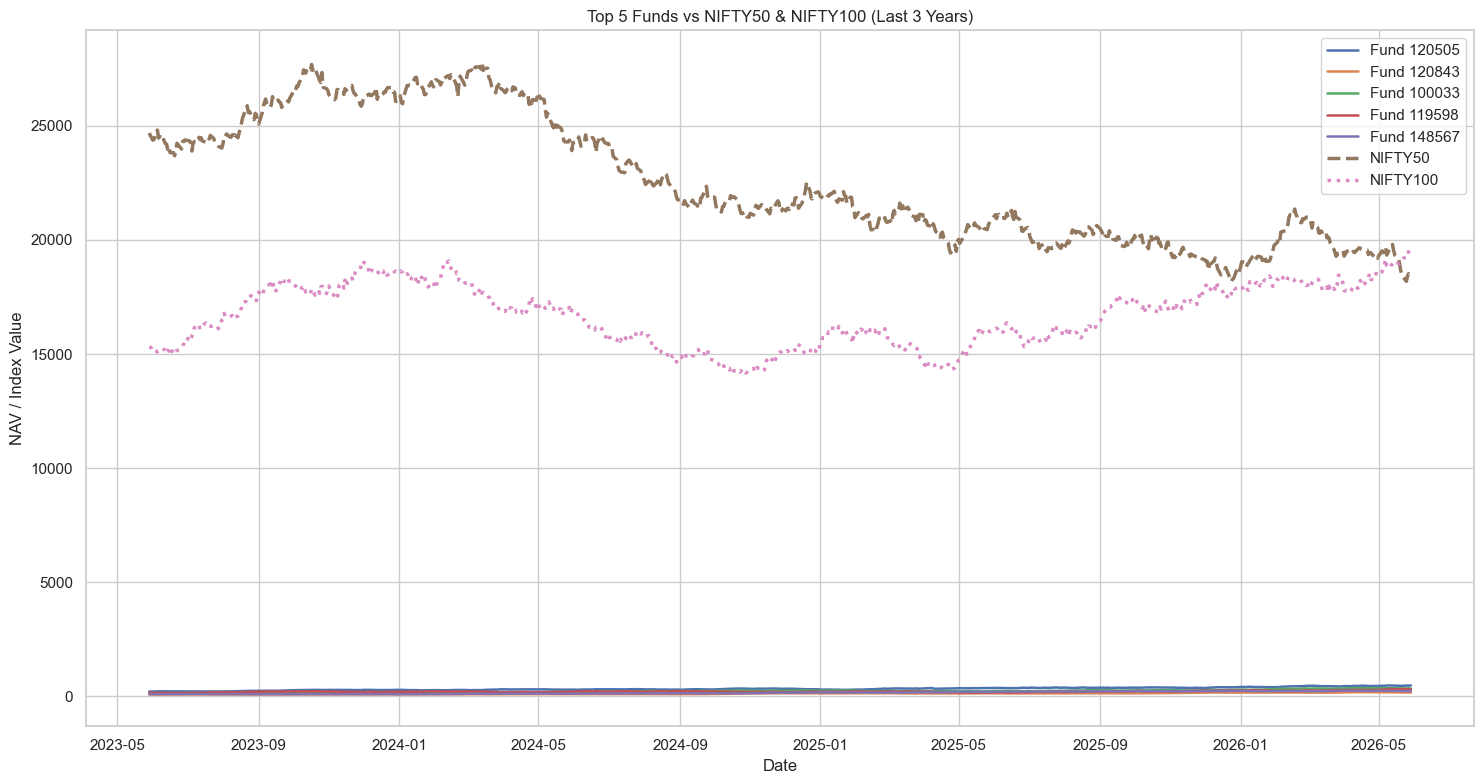

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

# Plot Top 5 Funds
for fund in top5_codes:

    fund_data = nav_3yr[
        nav_3yr["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        linewidth=1.8,
        label=f"Fund {fund}"
    )

# Plot NIFTY50
n50 = benchmark_3yr[
    benchmark_3yr["index_name"] == "NIFTY50"
]

plt.plot(
    n50["date"],
    n50["close_value"],
    linestyle="--",
    linewidth=2.5,
    label="NIFTY50"
)

# Plot NIFTY100
n100 = benchmark_3yr[
    benchmark_3yr["index_name"] == "NIFTY100"
]

plt.plot(
    n100["date"],
    n100["close_value"],
    linestyle=":",
    linewidth=2.5,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")

plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
tracking_error_results = []

benchmark_returns = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

for fund in top5_codes:

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        benchmark_returns,
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": fund,
        "Tracking_Error": round(tracking_error,6)
    })

tracking_error_df = pd.DataFrame(tracking_error_results)

print(tracking_error_df)

   amfi_code  Tracking_Error
0     120505        0.231968
1     120843        0.206425
2     100033        0.228699
3     119598        0.283881
4     148567        0.189664


### Observation 8

The benchmark comparison shows how the top-ranked mutual funds performed relative to the NIFTY50 and NIFTY100 indices over the last three years. Tracking Error quantifies how closely each fund followed the benchmark, with lower values indicating closer benchmark replication.

In [29]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print("Saved tracking_error.csv")

Saved tracking_error.csv
